# Contrasive Learning for Pneumonia Detection Using Chest X-Rays

In [3]:
import sys
from pathlib import Path
# Add parent directory to sys.path
sys.path.append(str(Path().resolve().parent.parent))

In [4]:
# Imports
from pneumonia_detection.dataset import ChestXRayDataset, get_dataloaders
from pneumonia_detection.visualize_dataset import (
    count_images,
    plot_dataset_statistics,
    show_sample_images,
    get_class_distribution,
    plot_class_distribution,
    show_samples_from_dataset
)



In [5]:
# Load dataloaders
train_loader, val_loader, test_loader = get_dataloaders()

# Load raw dataset
train_dataset = ChestXRayDataset(split="train")

# 2. Show class distribution numbers
class_counts = get_class_distribution(train_dataset)
print("Class Distribution:", class_counts)


Class Distribution: {0: 1341, 1: 3875}


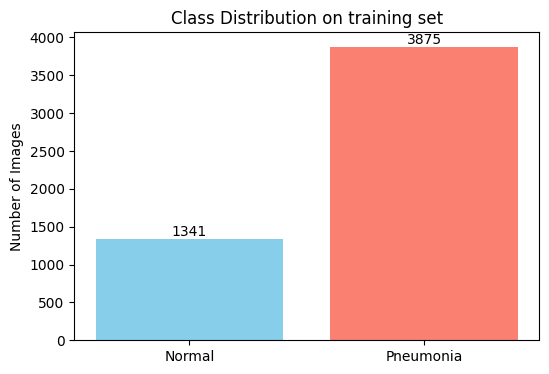

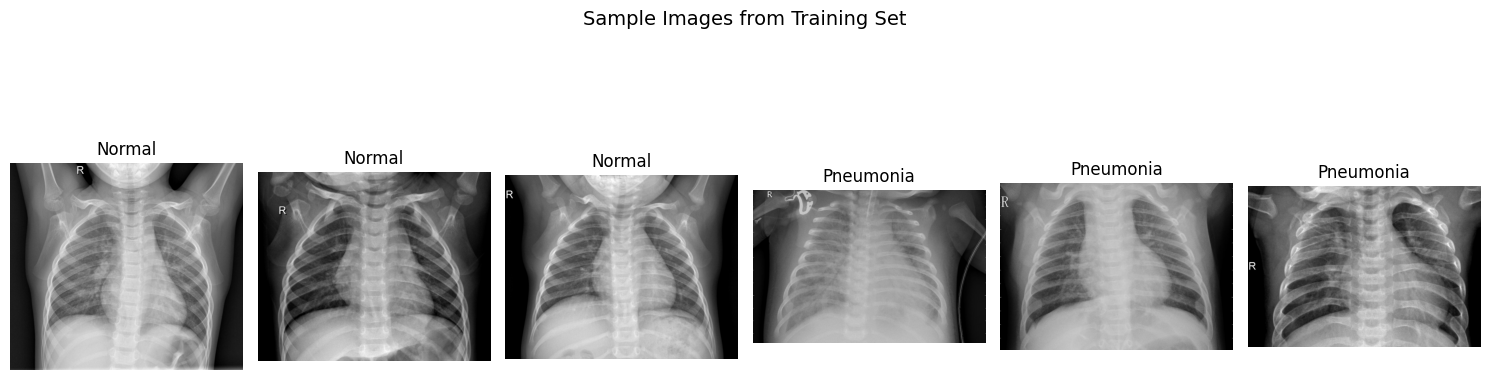

In [6]:
# 3. Plot distribution graph
plot_class_distribution(class_counts, class_names=['Normal', 'Pneumonia'])

# 4. Show sample images
show_samples_from_dataset(train_dataset, class_names=['Normal', 'Pneumonia'], samples_per_class=3)

## CNN training

In [7]:
from pneumonia_detection.CNN.model import PneumoniaCNN
from pneumonia_detection.CNN.trainer import run_training
from pneumonia_detection.config import *

### Train on GPU

In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

import torch
print(torch.version.cuda)  # Should print CUDA version, not None
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")


cuda
11.8
True
1
NVIDIA GeForce RTX 3060 Ti


In [9]:
print(device)

cuda


 Import and Use the Augmentation 

In [20]:
from pneumonia_detection.augmentation.transformations import train_transform, test_val_transform
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import os

# Paths to data
data_dir = "H:/iut_project/pneumonia-detection/data/chest_xray"  # Update to the correct path
train_dir = os.path.join(data_dir, "train")
val_dir = os.path.join(data_dir, "val")
test_dir = os.path.join(data_dir, "test")

# Dataset objects with transformations
train_dataset = ImageFolder(train_dir, transform=train_transform)
val_dataset = ImageFolder(val_dir, transform=test_val_transform)
test_dataset = ImageFolder(test_dir, transform=test_val_transform)

# DataLoaders
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Class names
class_names = train_dataset.classes
print("Classes:", class_names)


Classes: ['NORMAL', 'PNEUMONIA']


In [17]:
import os

# Verify that subdirectories exist and have images
train_dir = Path("H:/iut_project/pneumonia-detection/data/chest_xray/train")
val_dir = Path("H:/iut_project/pneumonia-detection/data/chest_xray/val")
test_dir = Path("H:/iut_project/pneumonia-detection/data/chest_xray/test")

print(f"Train directory: {os.listdir(train_dir)}")
print(f"Validation directory: {os.listdir(val_dir)}")
print(f"Test directory: {os.listdir(test_dir)}")

print(f"Train NORMAL contents: {os.listdir(train_dir / 'NORMAL')}")
print(f"Train PNEUMONIA contents: {os.listdir(train_dir / 'PNEUMONIA')}")
print(f"Validation NORMAL contents: {os.listdir(val_dir / 'NORMAL')}")
print(f"Validation PNEUMONIA contents: {os.listdir(val_dir / 'PNEUMONIA')}")
print(f"Test NORMAL contents: {os.listdir(test_dir / 'NORMAL')}")
print(f"Test PNEUMONIA contents: {os.listdir(test_dir / 'PNEUMONIA')}")



Train directory: ['.DS_Store', 'NORMAL', 'PNEUMONIA']
Validation directory: ['.DS_Store', 'NORMAL', 'PNEUMONIA']
Test directory: ['.DS_Store', 'NORMAL', 'PNEUMONIA']
Train NORMAL contents: ['.DS_Store', 'IM-0115-0001.jpeg', 'IM-0117-0001.jpeg', 'IM-0119-0001.jpeg', 'IM-0122-0001.jpeg', 'IM-0125-0001.jpeg', 'IM-0127-0001.jpeg', 'IM-0128-0001.jpeg', 'IM-0129-0001.jpeg', 'IM-0131-0001.jpeg', 'IM-0133-0001.jpeg', 'IM-0135-0001.jpeg', 'IM-0137-0001.jpeg', 'IM-0140-0001.jpeg', 'IM-0141-0001.jpeg', 'IM-0143-0001.jpeg', 'IM-0145-0001.jpeg', 'IM-0147-0001.jpeg', 'IM-0149-0001.jpeg', 'IM-0151-0001.jpeg', 'IM-0152-0001.jpeg', 'IM-0154-0001.jpeg', 'IM-0156-0001.jpeg', 'IM-0158-0001.jpeg', 'IM-0160-0001.jpeg', 'IM-0162-0001.jpeg', 'IM-0164-0001.jpeg', 'IM-0166-0001.jpeg', 'IM-0168-0001.jpeg', 'IM-0170-0001.jpeg', 'IM-0172-0001.jpeg', 'IM-0176-0001.jpeg', 'IM-0177-0001.jpeg', 'IM-0178-0001.jpeg', 'IM-0180-0001.jpeg', 'IM-0182-0001.jpeg', 'IM-0183-0001.jpeg', 'IM-0185-0001.jpeg', 'IM-0187-0001.jpeg',

In [15]:
print(f"BASE_DIR: {BASE_DIR}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"MODEL_DIR: {MODEL_DIR}")


BASE_DIR: H:\iut_project\pneumonia-detection
DATA_DIR: H:\iut_project\pneumonia-detection\data\chest_xray
MODEL_DIR: H:\iut_project\pneumonia-detection\models


In [19]:
from torchvision.datasets import ImageFolder
import os

# Function to filter out .DS_Store files
def is_valid_file(filename):
    return not filename.startswith('.')

# Define dataset paths
train_dir = "H:/iut_project/pneumonia-detection/data/chest_xray/train"
val_dir = "H:/iut_project/pneumonia-detection/data/chest_xray/val"
test_dir = "H:/iut_project/pneumonia-detection/data/chest_xray/test"

# Load datasets with the exclusion of .DS_Store files
train_dataset = ImageFolder(train_dir, transform=train_transform, is_valid_file=is_valid_file)
val_dataset = ImageFolder(val_dir, transform=test_val_transform, is_valid_file=is_valid_file)
test_dataset = ImageFolder(test_dir, transform=test_val_transform, is_valid_file=is_valid_file)

# Print the number of images loaded
print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")


Train dataset size: 5218
Validation dataset size: 18
Test dataset size: 624


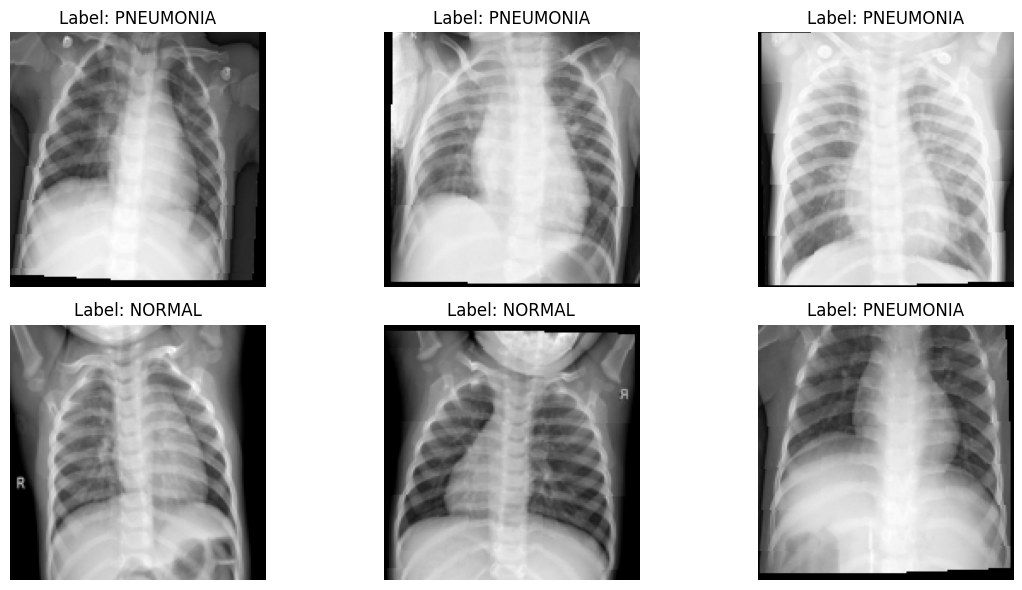

In [22]:
import matplotlib.pyplot as plt

# Get a batch of training data
images, labels = next(iter(train_loader))

# Denormalize function to unnormalize the images (bring them back to [0, 1] range)
def denormalize(img):
    img = img * 0.5 + 0.5  # Unnormalize
    return img

# Plot a few images
plt.figure(figsize=(12, 6))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    img = denormalize(images[i]).squeeze().numpy()
    plt.imshow(img, cmap="gray")
    plt.title(f"Label: {class_names[labels[i]]}")
    plt.axis("off")
plt.tight_layout()
plt.show()
